# Figure 3D (UHVDB r6). Lifestyle information

Revision of `figure_3d.ipynb` using the released UHVDB r6 metadata table
(`toolkit2/databases/uhvdb/v6/analyze/uhvdb_metadata.tsv.gz`).

Lifestyle evidence is already joined into that table
(`integration_status`, `temperate`/`virulent`, `phrog_integrases`,
`phrog_integration_excision`, `empathi_integration`, `topology`, `provirus`),
so the intermediate BACPHLIP / Pharokka / Phold / Empathi rebuild is not needed.

Body-site stacked bars exclude `Other` and `Blood` (same as `figure_3b_revision`).


In [1]:
### Load packages
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

META = Path(
    "/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB"
    "/toolkit2/databases/uhvdb/v6/analyze/uhvdb_metadata.tsv.gz"
)
OUTDIR = Path("plots")
OUTDIR.mkdir(exist_ok=True)

EXCLUDE_BODY_SITES = {"Other", "Blood"}


In [2]:
### Load UHVDB r6 metadata (genomovar representatives only)
meta = pl.read_csv(
    META,
    separator="\t",
    null_values=["NA", ""],
    columns=[
        "uhvdb_id",
        "genomovar_rep",
        "seq_name",
        "seqhash_rep",
        "body_site",
        "topology",
        "provirus",
        "integration_status",
        "temperate",
        "virulent",
        "phrog_integrases",
        "phrog_integration_excision",
        "empathi_integration",
    ],
    infer_schema_length=10000,
)

genomovars = meta.filter(
    (pl.col("uhvdb_id") == pl.col("genomovar_rep"))
    & (pl.col("seq_name") == pl.col("seqhash_rep"))
)

print(f"total genomovar reps: {genomovars.height:,}")
print(genomovars.group_by("body_site").len().sort("len", descending=True))
print(genomovars.group_by("integration_status").len().sort("len", descending=True))


total genomovar reps: 925,479
shape: (6, 2)
┌────────────┬────────┐
│ body_site  ┆ len    │
│ ---        ┆ ---    │
│ str        ┆ u32    │
╞════════════╪════════╡
│ Gut        ┆ 532722 │
│ Airways    ┆ 282136 │
│ Other      ┆ 85166  │
│ Blood      ┆ 9539   │
│ Skin       ┆ 8363   │
│ Urogenital ┆ 7553   │
└────────────┴────────┘
shape: (2, 2)
┌────────────────────┬────────┐
│ integration_status ┆ len    │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ unintegrated       ┆ 804648 │
│ integrated         ┆ 120831 │
└────────────────────┴────────┘


In [3]:
### Classify temperate vs virulent (same priority as figure_3d)
# Temperate if any of:
#   1) integration evidence (r6 integration_status / topology / provirus)
#   2) BACPHLIP temperate score > 0.5
#   3) Pharokka/Phold integrase annotation
#   4) Pharokka/Phold integration-and-excision category
#   5) Empathi integration annotation
classified = (
    genomovars
    .filter(pl.col("body_site").is_not_null())
    .with_columns([
        (
            (pl.col("integration_status").str.to_lowercase() == "integrated")
            | (pl.col("topology") == "Provirus")
            | (pl.col("provirus") == "Yes")
        ).alias("has_integration"),
        (pl.col("temperate").cast(pl.Float64, strict=False) > 0.5).fill_null(False).alias("has_bacphlip_temperate"),
        (pl.col("phrog_integrases").fill_null(0) > 0).alias("has_phrog_integrase"),
        (pl.col("phrog_integration_excision").fill_null(0) > 0).alias("has_phrog_integration_excision"),
        (pl.col("empathi_integration").fill_null(0) > 0).alias("has_empathi_integration"),
    ])
    .with_columns(
        pl.when(
            pl.col("has_integration")
            | pl.col("has_bacphlip_temperate")
            | pl.col("has_phrog_integrase")
            | pl.col("has_phrog_integration_excision")
            | pl.col("has_empathi_integration")
        )
        .then(pl.lit("Temperate"))
        .otherwise(pl.lit("Virulent"))
        .alias("lifestyle")
    )
)

print(f"Total genomovars: {classified.height:,}")
print(
    "Temperate:",
    classified.filter(pl.col("lifestyle") == "Temperate").height,
    "/",
    classified.height,
    f"({classified.filter(pl.col('lifestyle') == 'Temperate').height / classified.height:.2%})",
)
classified.group_by("lifestyle").len().sort("lifestyle")


Total genomovars: 925,479
Temperate: 691980 / 925479 (74.77%)


lifestyle,len
str,u32
"""Temperate""",691980
"""Virulent""",233499


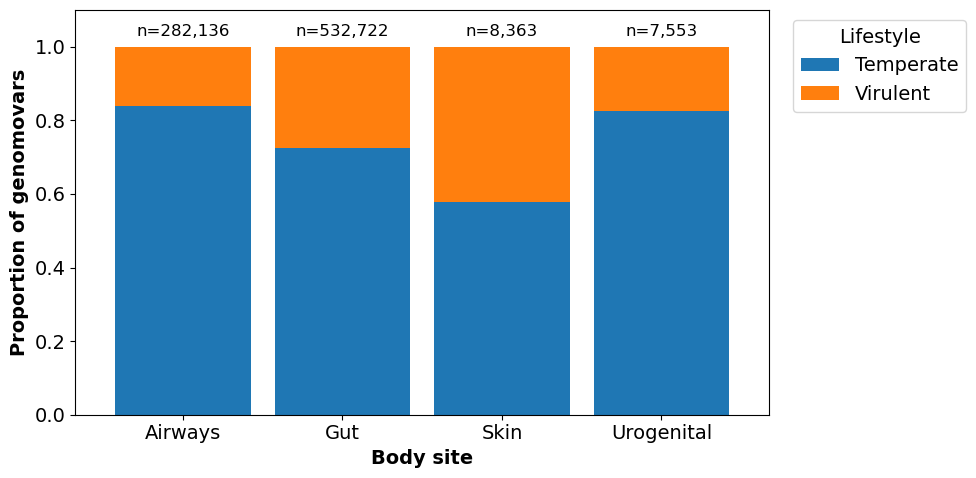

lifestyle,Temperate,Virulent
body_site,,
Airways,0.840251,0.159749
Gut,0.725513,0.274487
Skin,0.579098,0.420902
Urogenital,0.825500,0.174500


In [4]:
### Stacked temperate / virulent proportions by body site
plt.rcParams.update({"font.size": 14})
method_order = ["Temperate", "Virulent"]

plot_genomovars = classified.filter(~pl.col("body_site").is_in(list(EXCLUDE_BODY_SITES)))

site_counts = (
    plot_genomovars
    .group_by(["body_site", "lifestyle"])
    .len()
    .rename({"len": "count"})
)
site_totals = (
    plot_genomovars
    .group_by("body_site")
    .len()
    .rename({"len": "total"})
)

body_method_props = (
    plot_genomovars.select("body_site").unique()
    .join(pl.DataFrame({"lifestyle": method_order}), how="cross")
    .join(site_counts, on=["body_site", "lifestyle"], how="left")
    .join(site_totals, on="body_site", how="left")
    .with_columns([
        pl.col("count").fill_null(0),
        (pl.col("count").fill_null(0) / pl.col("total")).alias("proportion"),
    ])
    .select(["body_site", "lifestyle", "count", "proportion"])
)

pivot_df = (
    body_method_props.to_pandas()
    .pivot(index="body_site", columns="lifestyle", values="proportion")
    .fillna(0)
)[method_order]

site_total_pdf = site_totals.to_pandas().set_index("body_site").reindex(pivot_df.index)

ax = pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    width=0.85,
)
ax.set_xlabel("Body site", fontdict={"fontweight": "bold"})
ax.set_ylabel("Proportion of genomovars", fontdict={"fontweight": "bold"})
ax.legend(title="Lifestyle", bbox_to_anchor=(1.02, 1), loc="upper left")

for i, body_site in enumerate(pivot_df.index):
    total = int(site_total_pdf.loc[body_site, "total"])
    ax.text(i, 1.02, f"n={total:,}", ha="center", va="bottom", fontsize=12)

ax.set_ylim(0, 1.10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTDIR / "figure_3d_lifestyle_by_body_site_r6.png", dpi=300, bbox_inches="tight")
plt.show()

pivot_df


In [5]:
print("Total number of genomovars:", classified.height)
print(
    "Total number of temperate genomovars:",
    classified.filter(pl.col("lifestyle") == "Temperate").height,
)
print(
    "Proportion of temperate genomovars:",
    classified.filter(pl.col("lifestyle") == "Temperate").height / classified.height,
)


Total number of genomovars: 925479
Total number of temperate genomovars: 691980
Proportion of temperate genomovars: 0.7476992994978816


shape: (3, 3)
┌─────────────┬────────┬────────────┐
│ threshold   ┆ count  ┆ proportion │
│ ---         ┆ ---    ┆ ---        │
│ str         ┆ i64    ┆ f64        │
╞═════════════╪════════╪════════════╡
│ 0 signals   ┆ 233499 ┆ 0.252301   │
│ >=1 signal  ┆ 691980 ┆ 0.747699   │
│ >=2 signals ┆ 419188 ┆ 0.452942   │
└─────────────┴────────┴────────────┘


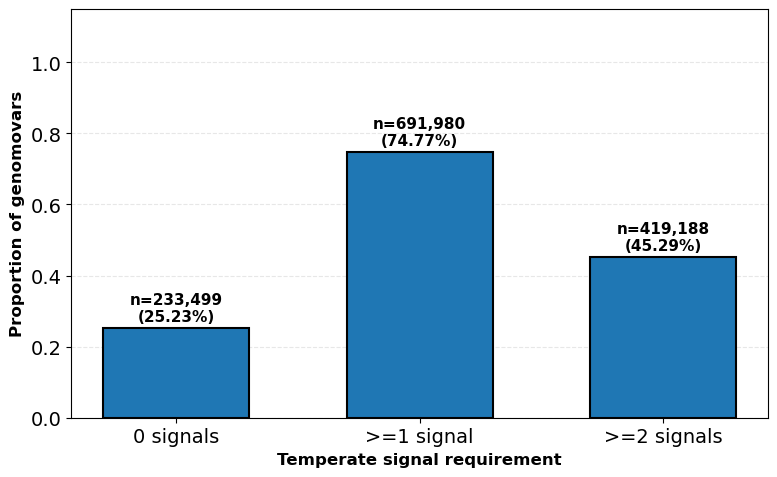

In [6]:
### Proportion of genomovars with 0, >=1, and >=2 temperate signals
# Signal definition matches figure_3d:
#   1) integration evidence
#   2) BACPHLIP temperate > 0.5
#   3) any of phrog integrase / integration-excision / Empathi integration
signal_counts = classified.with_columns(
    (
        pl.col("has_integration").cast(pl.Int32)
        + pl.col("has_bacphlip_temperate").cast(pl.Int32)
        + (
            pl.col("has_phrog_integrase")
            | pl.col("has_phrog_integration_excision")
            | pl.col("has_empathi_integration")
        ).cast(pl.Int32)
    ).alias("temperate_signal_count")
)

total_count = signal_counts.height
threshold_proportions = []
for threshold in [0, 1, 2]:
    if threshold == 0:
        n_at_threshold = signal_counts.filter(pl.col("temperate_signal_count") == 0).height
        label = "0 signals"
    else:
        n_at_threshold = signal_counts.filter(pl.col("temperate_signal_count") >= threshold).height
        label = f">={threshold} signal{'s' if threshold != 1 else ''}"
    threshold_proportions.append({
        "threshold": label,
        "count": n_at_threshold,
        "proportion": n_at_threshold / total_count,
    })

threshold_df = pl.DataFrame(threshold_proportions)
print(threshold_df)

fig, ax = plt.subplots(figsize=(8, 5))
threshold_df_pd = threshold_df.to_pandas()
bars = ax.bar(
    threshold_df_pd["threshold"],
    threshold_df_pd["proportion"],
    width=0.6,
    edgecolor="black",
    linewidth=1.5,
)
for bar, count in zip(bars, threshold_df_pd["count"]):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.01,
        f"n={int(count):,}\n({height:.2%})",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_ylabel("Proportion of genomovars", fontdict={"fontweight": "bold"}, fontsize=12)
ax.set_xlabel("Temperate signal requirement", fontdict={"fontweight": "bold"}, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig(OUTDIR / "figure_3d_temperate_signal_thresholds_r6.png", dpi=300, bbox_inches="tight")
plt.show()
